# ML Config — Significant Taxa + Clinical + Pathway, Two Platform-Matched Models (PD-vs-HC / AD-vs-HC)

Same two-model fix as `ml_02_significant_taxa_two_models.ipynb` and
`ml_03_significant_taxa_clinical_two_models_lasso.ipynb`, extended with the
pathway block:

- **Model A - PD vs HC, shotgun-only**: PD-specific + shared significant taxa,
  clinical metadata, and the full HUMAnN3-derived pathway feature set.
- **Model B - AD vs HC, 16S-only**: AD-specific + shared significant taxa,
  clinical metadata, and the full PICRUSt2-derived pathway feature set.

**Why `pathway_columns` isn't filtered to a disease-specific significant set,
unlike the taxa block:** the original `ml_04` design already used the full
459-pathway union unfiltered ("largest feature set of the four configs"), not
an ANCOM-BC2/MaAsLin2-significant subset the way `significant_taxa_columns`
is for taxa. A true disease-specific significant-pathway split would need the
same treatment given to `pd_specific_genera.csv`/`ad_specific_genera.csv` -
i.e. separate `pd_significant_pathways.csv`/`ad_significant_pathways.csv`
exported from your MaAsLin2 runs. You have this in hand for PD (5
FDR-significant hits: `P164-PWY`, `UDPNAGSYN-PWY`, `OANTIGEN-PWY`,
`PWY-7357`, `PWY-6897`) but **AD has zero pathways at q<0.05** - so an
AD-specific significant-pathway list would be empty at your thesis's own
q<0.05 standard. Using the full pathway union for both models sidesteps that
problem entirely for now; if you later want the stricter PD-only 5-pathway
version, see the commented-out override in Step 3 below.

**Why the platform-scale mismatch that made `ml_04`'s original 3-class
design risky (pathway values differ up to ~80x in raw magnitude between
HUMAnN3/shotgun and PICRUSt2/16S, e.g. `pathway__TCA` mean 3568 in 16S vs 45
in shotgun) is no longer a leakage risk here:** each model only ever sees
samples from ONE platform, so there is no cross-platform magnitude contrast
for the classifier to exploit. This is the same benefit the two-model split
already gave the taxa blocks.

**Expect this to be the slowest of the four configs to run** - LASSO
(`LogisticRegressionCV`, `saga` solver, `Cs=10`, inner `cv=5`) now runs over
~500 features per fold instead of ~44, and Model A's `wallen2022` fold alone
has 724 samples. Let it run in the background if needed.

**Keep the updated `ml_pipeline_utils.py` in the same folder as this
notebook.**


In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path

# sys.path.append("/path/to/folder/containing/ml_pipeline_utils.py")  # uncomment and edit if needed
from ml_pipeline_utils import (
    RANDOM_STATE, run_hyperparameter_search, run_loso_evaluation_with_lasso, fit_final_lasso_selector,
    match_taxon_columns, run_loso_evaluation, plot_confusion_matrix, run_shap_analysis, save_artifacts,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

import joblib

## Step 1 - Load the master feature table and column lists

In [2]:
# ---- EDIT THESE PATHS ----
# FEATURE_TABLE_DIR = Path("/rds/projects/e/elhamsak-pd-thesis/processed/ml_feature_table")
# OUTPUT_DIR = Path("/rds/projects/e/elhamsak-pd-thesis/results/ml_config_sig_taxa_two_models")
FEATURE_TABLE_DIR = Path("ml_feature_table")
OUTPUT_DIR = Path("ml_config4_shared_taxa_clinical_pathway_two_models_lasso")
# ---------------------------

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

master = pd.read_csv(FEATURE_TABLE_DIR / "ml_master_feature_table.csv", index_col=0)

def load_list(path):
    with open(path) as f:
        return [line.strip() for line in f if line.strip()]

all_taxa_columns         = load_list(FEATURE_TABLE_DIR / "all_taxa_columns.txt")
significant_taxa_columns = load_list(FEATURE_TABLE_DIR / "significant_taxa_columns.txt")
clinical_columns         = load_list(FEATURE_TABLE_DIR / "clinical_columns.txt")
pathway_columns          = load_list(FEATURE_TABLE_DIR / "pathway_columns.txt")

print("Master table:", master.shape)
print(master["disease_group"].value_counts())
print(master.groupby(["disease_group", "platform"]).size())

Master table: (1829, 751)
disease_group
HC    755
PD    751
AD    323
Name: count, dtype: int64
disease_group  platform
AD             16S         323
HC             16S         294
               shotgun     461
PD             shotgun     751
dtype: int64


## Step 2 - Confirm the master table is what you expect

In [3]:
assert master[all_taxa_columns].isna().sum().sum() == 0, "Unexpected NaNs in taxa columns"
assert master[clinical_columns].isna().sum().sum() == 0, "Unexpected NaNs in clinical columns"
assert master[pathway_columns].isna().sum().sum() == 0, "Unexpected NaNs in pathway columns"
print("No unexpected NaNs found in the feature blocks - good to proceed.")

No unexpected NaNs found in the feature blocks - good to proceed.


## Step 3 - Select this notebook's feature set

Same as `ml_02`: the ANCOM-BC2-significant genera union (PD-specific +
AD-specific + shared). We keep this shared feature set for both models below
so the comparison in Step 8 is apples-to-apples; if `ml_00` later exports
disease-specific significant-taxa lists, each model could instead use only
its own disease's significant genera - a worthwhile refinement, not done here
to keep this change minimal ahead of the deadline.

In [4]:
feature_cols = significant_taxa_columns + clinical_columns + pathway_columns
print(f"(placeholder - overwritten below with disease-specific taxa + clinical + pathway) Using {len(feature_cols)} features.")


(placeholder - overwritten below with disease-specific taxa + clinical + pathway) Using 508 features.


In [5]:
# ---- EDIT THIS: local copies of the ANCOM-BC2 disease-specific outputs ----
PD_SPECIFIC_CSV = Path("pd_specific_genera.csv")
AD_SPECIFIC_CSV = Path("ad_specific_genera.csv")
# -----------------------------------------------------------------------

shared_taxa = ["g__Enterococcus", "g__Roseburia", "g__Haemophilus", "g__Clostridium",
               "g__Faecalibacterium", "g__Eisenbergiella", "g__Lachnospira"]

pd_specific_taxa = pd.read_csv(PD_SPECIFIC_CSV)["taxon"].tolist()
ad_specific_taxa = pd.read_csv(AD_SPECIFIC_CSV)["taxon"].tolist()

shared_cols      = match_taxon_columns(shared_taxa, all_taxa_columns, label="shared taxa")
pd_specific_cols = match_taxon_columns(pd_specific_taxa, all_taxa_columns, label="PD-specific taxa")
ad_specific_cols = match_taxon_columns(ad_specific_taxa, all_taxa_columns, label="AD-specific taxa")

pd_taxa_cols = sorted(set(shared_cols) | set(pd_specific_cols))
ad_taxa_cols = sorted(set(shared_cols) | set(ad_specific_cols))

# Pathway block: full union for both models (see markdown above for why this
# isn't filtered to a disease-specific significant subset the way taxa are).
# --- OPTIONAL STRICTER OVERRIDE (uncomment to use PD's 5 FDR-significant
# pathways only, instead of the full 459-pathway union, for Model A - AD has
# no q<0.05 pathways so there is no equivalent override for Model B): ---
# pd_significant_pathways = ["P164-PWY", "UDPNAGSYN-PWY", "OANTIGEN-PWY", "PWY-7357", "PWY-6897"]
# pd_pathway_cols = match_taxon_columns(pd_significant_pathways, pathway_columns,
#                                        label="PD-significant pathways", prefix="pathway__", strip_prefix="")
# else: use the full union below (default)
pd_pathway_cols = pathway_columns
ad_pathway_cols = pathway_columns

pd_feature_cols = pd_taxa_cols + clinical_columns + pd_pathway_cols
ad_feature_cols = ad_taxa_cols + clinical_columns + ad_pathway_cols

print(f"Model A (PD vs HC) features: {len(pd_feature_cols)} "
      f"({len(pd_specific_cols)} PD-specific taxa + {len(shared_cols)} shared taxa + "
      f"{len(clinical_columns)} clinical + {len(pd_pathway_cols)} pathway)")
print(f"Model B (AD vs HC) features: {len(ad_feature_cols)} "
      f"({len(ad_specific_cols)} AD-specific taxa + {len(shared_cols)} shared taxa + "
      f"{len(clinical_columns)} clinical + {len(ad_pathway_cols)} pathway)")


Model A (PD vs HC) features: 503 (31 PD-specific taxa + 7 shared taxa + 6 clinical + 459 pathway)
Model B (AD vs HC) features: 484 (12 AD-specific taxa + 7 shared taxa + 6 clinical + 459 pathway)


## Step 4 - Split into two platform-matched subsets (replaces the platform-leakage diagnostic)

This is the actual fix. Each subset below is restricted to a single
platform, so within either model there is no shotgun/16S axis left for the
classifier to find - "which platform" and "which class" are no longer
confounded because platform is now constant within each model.

- **Model A (shotgun-only): PD vs HC** - drops the 16S-only HC samples.
- **Model B (16S-only): AD vs HC** - drops the shotgun-only HC samples.

The assertions below aren't decorative - they're the thing that actually
proves the fix worked: `platform.nunique() == 1` in each subset means the
confound is gone by construction, not by hope.

In [6]:
pd_df = master[(master["disease_group"].isin(["PD","HC",])) & (master["platform"] == "shotgun")].reset_index(drop=True)
ad_df = master[(master["disease_group"].isin(["AD","HC",])) & (master["platform"] == "16S")].reset_index(drop=True)

assert (pd_df["platform"].nunique()== 1)
assert (ad_df["platform"].nunique()== 1)

print("\n Model A - PD vs HC (shotgun-only)")
print(pd_df["disease_group"].value_counts())
print("\n ModeL B - AD vs HC (16S-only)")
print(ad_df["disease_group"].value_counts())

# Sanity check: confirm we haven't silently dropped every HC sample from
# either subset (would happen if the platform column values don't match
# "shotgun"/"16S" exactly - fail loudly instead of training on an empty class)
assert pd_df["disease_group"].value_counts().min() > 0, "One class is empty in the PD/HC subset - check platform label spelling"
assert ad_df["disease_group"].value_counts().min() > 0, "One class is empty in the AD/HC subset - check platform label spelling"


 Model A - PD vs HC (shotgun-only)
disease_group
PD    751
HC    461
Name: count, dtype: int64

 ModeL B - AD vs HC (16S-only)
disease_group
AD    323
HC    294
Name: count, dtype: int64


## Step 5 - One function, run twice

Steps 5-10 of the original `ml_02` (encode labels, scale, tune, LOSO-evaluate,
confusion matrix, SHAP, save artifacts) are identical in shape for both
models - only the input subset and an output subfolder differ. Wrapping that
in one function keeps the two runs from drifting apart the way copy-pasted
notebook cells tend to.

`n_splits` for the inner hyperparameter search is capped at the smaller
class's study count (never below 2), since `StratifiedGroupKFold` needs at
least that many groups per class - the same guard `check_platform_leakage`
already uses elsewhere in this pipeline.

In [7]:
def run_one_model(df,feature_cols,model_label,output_subdir,):
    print(f"\n{'='*70}\n"
          f"Running model: "
          f"{model_label}\n"
          f"{'='*70}"
          )
    sub_output_dir = (
        OUTPUT_DIR /
        output_subdir
    )

    sub_output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    # ======================================================
    # LABEL ENCODING
    # ======================================================
    label_encoder = LabelEncoder()
    df = df.copy()
    df["y"] = label_encoder.fit_transform(df["disease_group"])
    print("Class encoding:",dict(zip(label_encoder.classes_,label_encoder.transform(label_encoder.classes_))))

    X = df[feature_cols].values
    y = df["y"].values
    groups = df["study_id"].values

    print(f"Initial feature count: {len(feature_cols)}")

    # ======================================================
    # INNER CV SPLITS
    # ======================================================
    n_studies_per_class = (df.groupby("disease_group")["study_id"].nunique())
    n_splits = max(2,min(5,int(n_studies_per_class.min())))

    # ======================================================
    # RF HYPERPARAMETER SEARCH
    # ======================================================
    grid = run_hyperparameter_search(X,y,groups,n_splits=n_splits,)

    # ======================================================
    # LOSO + LASSO
    # ======================================================
    (
        loso_df,
        all_y_true,
        all_y_pred,
        all_y_proba,
    ) = run_loso_evaluation_with_lasso(
        X=X,
        y=y,
        groups=groups,
        feature_cols=feature_cols,
        best_params=grid.best_params_,
        label_encoder=label_encoder,
        output_dir=sub_output_dir,
        min_features=1,
    )

    # ======================================================
    # CONFUSION MATRIX
    # ======================================================
    cm_df = plot_confusion_matrix(all_y_true,all_y_pred,label_encoder,sub_output_dir,)

    # ======================================================
    # STUDY-LEVEL METRICS
    # ======================================================
    print("\nStudy-level LOSO metrics:")
    display(loso_df.sort_values("f1_macro"))

    # ======================================================
    # FINAL LASSO
    # ======================================================
    (
        final_selected_indices,
        final_selected_features,
        final_lasso_scaler,
        final_lasso_model,
    ) = fit_final_lasso_selector(
        X=X,
        y=y,
        feature_cols=feature_cols,
        min_features=1,
    )

    # ======================================================
    # FINAL RF
    # ======================================================
    X_final = X[:,final_selected_indices]
    final_model = RandomForestClassifier(**grid.best_params_,class_weight="balanced",random_state=RANDOM_STATE,n_jobs=-1,)
    final_model.fit(X_final,y,)

    # ======================================================
    # SHAP
    # ======================================================
    shap_values = run_shap_analysis(final_model,X_final,final_selected_features,label_encoder,sub_output_dir,max_display=30,)

    # ======================================================
    # SAVE
    # ======================================================
    save_artifacts(final_model,None,label_encoder,final_selected_features,sub_output_dir,)

    joblib.dump(final_lasso_scaler,sub_output_dir / "lasso_scaler.joblib",)
    joblib.dump(final_lasso_model,sub_output_dir / "lasso_selector.joblib",)
    return {"model_label":model_label,
            "label_encoder":label_encoder,
            "final_model":final_model,
            "final_selected_features":final_selected_features,
            "grid":grid,
            "loso_df":loso_df,
            "cm_df":cm_df,
            "shap_values":shap_values,
            }

## Step 6 - Model A: PD vs HC (shotgun-only)


Running model: PD vs HC (shotgun-only, PD-specific+shared taxa + clinical + pathway)
Class encoding: {'HC': np.int64(0), 'PD': np.int64(1)}
Initial feature count: 503
Fitting 5 folds for each of 27 candidates, totalling 135 fits


Best params: {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 500}
Best CV f1_macro: 0.6303760065581019

Fold 0 (held out bedarf2017)
LASSO selected 40/503 features
n=59, classes_present=2/2, Accuracy=0.542, F1_macro=0.515, AUC=0.563

Fold 1 (held out boktor2023_rumc)
LASSO selected 149/503 features
n=113, classes_present=2/2, Accuracy=0.690, F1_macro=0.670, AUC=0.830

Fold 2 (held out boktor2023_tbc)
LASSO selected 503/503 features
n=112, classes_present=2/2, Accuracy=0.625, F1_macro=0.619, AUC=0.848

Fold 3 (held out clasen2024)
LASSO selected 35/503 features
n=126, classes_present=2/2, Accuracy=0.817, F1_macro=0.552, AUC=0.862

Fold 4 (held out mao2021)
LASSO selected 38/503 features
n=78, classes_present=2/2, Accuracy=0.641, F1_macro=0.603, AUC=0.814

Fold 5 (held out wallen2022)
LASSO selected 91/503 features
n=724, classes_present=2/2, Accuracy=0.570, F1_macro=0.567, AUC=0.659

--- LOSO summary (pooled out-of-fold predictions across all folds) ---
Pooled AUC (binary): 0.

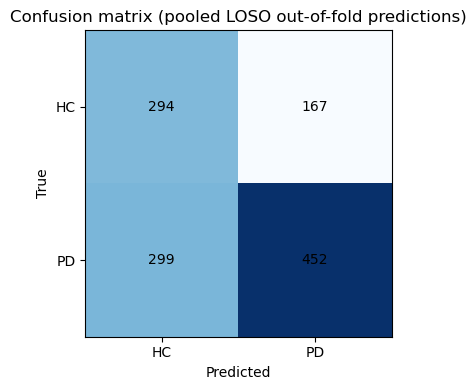

              precision    recall  f1-score   support

          HC       0.50      0.64      0.56       461
          PD       0.73      0.60      0.66       751

    accuracy                           0.62      1212
   macro avg       0.61      0.62      0.61      1212
weighted avg       0.64      0.62      0.62      1212


Study-level LOSO metrics:


,held_out_study,n_test_samples,n_classes_present,n_selected_features,selected_features,accuracy,f1_macro,auc,actual_HC,actual_PD,predicted_HC,predicted_PD
0,bedarf2017,59,2,40,taxon__g__Anaerotruncus;taxon__g__Candidatus_W...,0.542373,0.515068,0.563364,28,31,45,14
3,clasen2024,126,2,35,taxon__g__Anaerotruncus;taxon__g__Candidatus_W...,0.817460,0.551879,0.862325,22,104,7,119
5,wallen2022,724,2,91,taxon__g__Blautia;taxon__g__Candidatus_Woodwar...,0.570442,0.566952,0.659341,234,490,425,299
4,mao2021,78,2,38,taxon__g__Anaerotruncus;taxon__g__Candidatus_W...,0.641026,0.603486,0.813938,39,39,15,63
2,boktor2023_tbc,112,2,503,taxon__g__Anaerostipes;taxon__g__Anaerotruncus...,0.625000,0.619048,0.847761,67,45,31,81
1,boktor2023_rumc,113,2,149,taxon__g__Anaerostipes;taxon__g__Blautia;taxon...,0.690265,0.670004,0.829645,71,42,70,43



Final full-data LASSO selection:
140 / 503 features retained
Generating SHAP beeswarm for class: HC


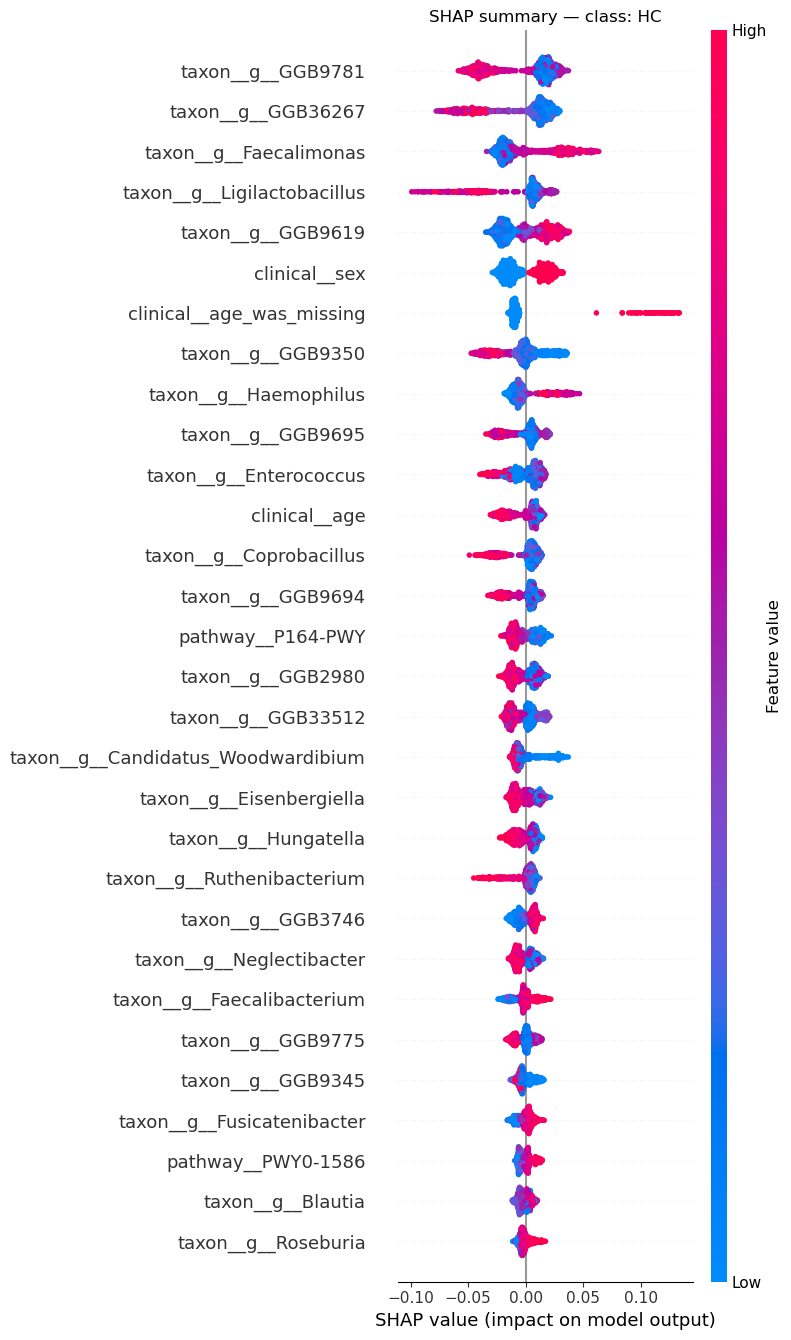

Generating SHAP beeswarm for class: PD


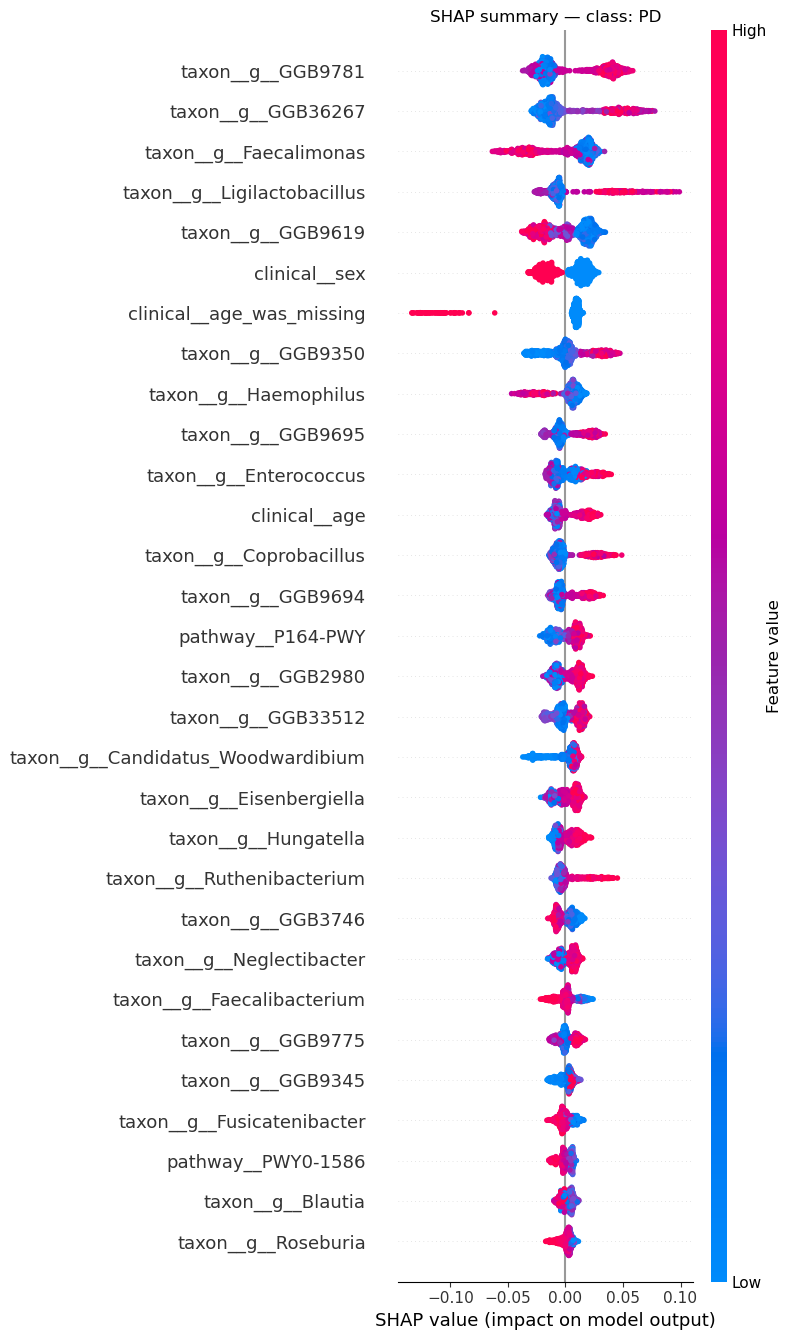

Saved model, scaler, label encoder, and feature list to: ml_config4_shared_taxa_clinical_pathway_two_models_lasso\pd_vs_hc_shotgun


<Figure size 640x480 with 0 Axes>

In [8]:
pd_results = run_one_model(pd_df, pd_feature_cols, "PD vs HC (shotgun-only, PD-specific+shared taxa + clinical + pathway)", "pd_vs_hc_shotgun",)


## Step 7 - Model B: AD vs HC (16S-only)


Running model: AD vs HC (16S-only, AD-specific+shared taxa + clinical + pathway)
Class encoding: {'AD': np.int64(0), 'HC': np.int64(1)}
Initial feature count: 484
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 300}
Best CV f1_macro: 0.4935216834358716

Fold 0 (held out binyinli2019)
LASSO selected 18/484 features
n=60, classes_present=2/2, Accuracy=0.533, F1_macro=0.529, AUC=0.469

Fold 1 (held out cirstea2022)
LASSO selected 144/484 features
n=98, classes_present=2/2, Accuracy=0.633, F1_macro=0.575, AUC=0.613

Fold 2 (held out ling2021)
LASSO selected 128/484 features
n=171, classes_present=2/2, Accuracy=0.620, F1_macro=0.474, AUC=0.674

Fold 3 (held out liu2019)
LASSO selected 23/484 features
n=61, classes_present=2/2, Accuracy=0.639, F1_macro=0.637, AUC=0.709

Fold 4 (held out ueda2021)
LASSO selected 27/484 features
n=7, classes_present=1/2, Accuracy=0.429, F1_macro=0.300, AUC=NA

Fold 5 (held 

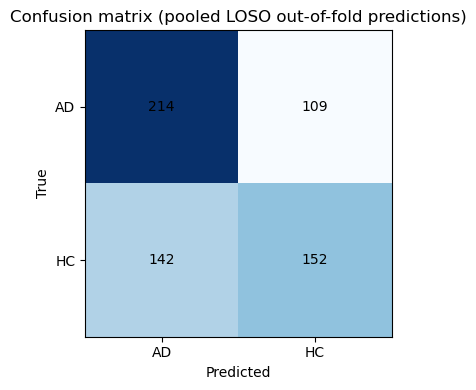

              precision    recall  f1-score   support

          AD       0.60      0.66      0.63       323
          HC       0.58      0.52      0.55       294

    accuracy                           0.59       617
   macro avg       0.59      0.59      0.59       617
weighted avg       0.59      0.59      0.59       617


Study-level LOSO metrics:


,held_out_study,n_test_samples,n_classes_present,n_selected_features,selected_features,accuracy,f1_macro,auc,actual_AD,actual_HC,predicted_AD,predicted_HC
4,ueda2021,7,1,27,taxon__g__Agathobaculum;taxon__g__Clostridium;...,0.428571,0.300000,NaN,7,0,3,4
5,yamashiro2024,37,2,145,taxon__g__Agathobacter;taxon__g__Agathobaculum...,0.513514,0.383333,0.695906,18,19,36,1
2,ling2021,171,2,128,taxon__g__Agathobacter;taxon__g__Bifidobacteri...,0.619883,0.474244,0.673944,100,71,161,10
0,binyinli2019,60,2,18,taxon__g__Agathobaculum;taxon__g__Haemophilus;...,0.533333,0.528620,0.468889,30,30,36,24
7,zhuang2018,86,2,140,taxon__g__Agathobaculum;taxon__g__Bifidobacter...,0.534884,0.532609,0.566793,43,43,49,37
1,cirstea2022,98,2,144,taxon__g__Clostridium;taxon__g__Enterococcus;t...,0.632653,0.575349,0.612998,45,53,17,81
6,yildirim2022,97,2,483,taxon__g__Agathobacter;taxon__g__Agathobaculum...,0.608247,0.592617,0.574468,47,50,31,66
3,liu2019,61,2,23,taxon__g__Agathobaculum;taxon__g__Clostridium;...,0.639344,0.636905,0.708874,33,28,23,38



Final full-data LASSO selection:
26 / 484 features retained
Generating SHAP beeswarm for class: AD


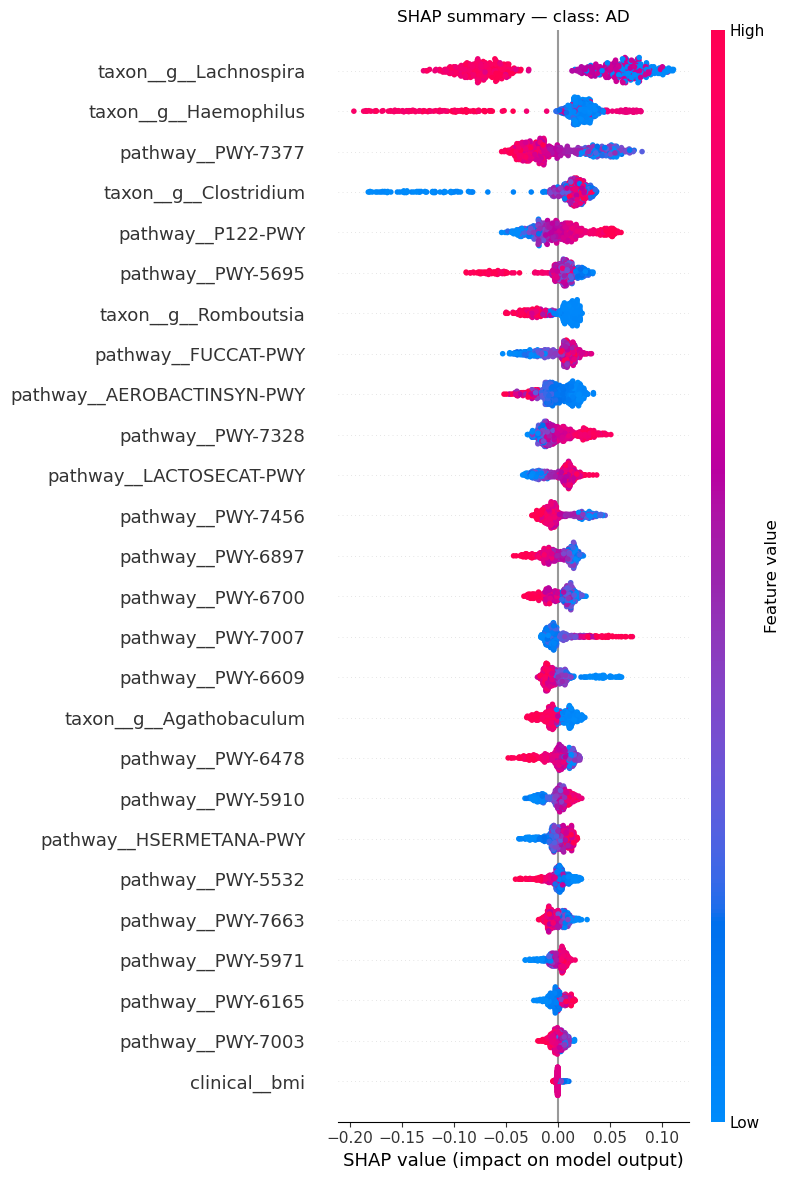

Generating SHAP beeswarm for class: HC


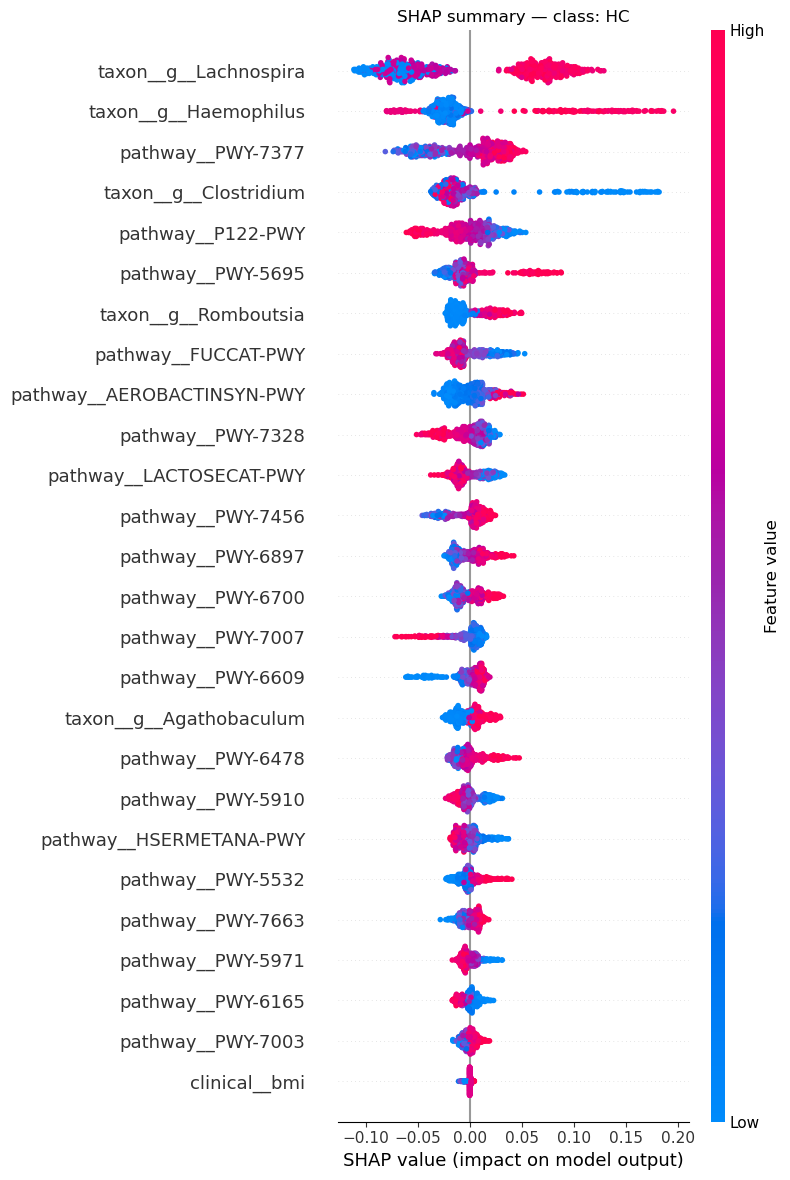

Saved model, scaler, label encoder, and feature list to: ml_config4_shared_taxa_clinical_pathway_two_models_lasso\ad_vs_hc_16s


<Figure size 640x480 with 0 Axes>

In [9]:
ad_results = run_one_model(ad_df, ad_feature_cols, "AD vs HC (16S-only, AD-specific+shared taxa + clinical + pathway)", "ad_vs_hc_16s",)


## Step 8 - Compare the two models' top taxa (qualitative, not a statistical test)

This is *not* a formal AD-vs-PD comparison - that comparison would need
studies running both diseases on the same platform, which don't exist here.
What this table gives you is a side-by-side of which significant genera each
disease-vs-HC model actually leaned on (Gini importance from each model's
final RF, plus which model each genus ranks higher in). Useful for a
"shared vs distinct candidate taxa" discussion in the thesis, framed
explicitly as suggestive rather than confirmatory given the platforms
differ.

In [10]:
pd_importances = pd.Series(pd_results["final_model"].feature_importances_,
                           index=pd_results["final_selected_features"], name="importance_PD_vs_HC")
ad_importances = pd.Series(ad_results["final_model"].feature_importances_,
                           index=ad_results["final_selected_features"], name="importance_AD_vs_HC")

comparison_df = pd.concat([pd_importances, ad_importances], axis=1)

comparison_df["in_model"] = np.select(
    [comparison_df["importance_PD_vs_HC"].notna() & comparison_df["importance_AD_vs_HC"].notna(),
     comparison_df["importance_PD_vs_HC"].notna()],
    ["both (post-LASSO)", "PD_vs_HC only"],
    default="AD_vs_HC only"
)

comparison_df["rank_PD_vs_HC"] = comparison_df["importance_PD_vs_HC"].rank(ascending=False)
comparison_df["rank_AD_vs_HC"] = comparison_df["importance_AD_vs_HC"].rank(ascending=False)

# Only meaningful for rows present in BOTH models' final LASSO-selected sets -
# NaN vs a rank always compares False in numpy, so the old np.where() version
# silently mislabelled every single-model row as "AD_vs_HC". Leave those blank.
comparison_df["higher_ranked_in"] = np.nan
both_mask = comparison_df["in_model"] == "both (post-LASSO)"
comparison_df.loc[both_mask, "higher_ranked_in"] = np.where(
    comparison_df.loc[both_mask, "rank_PD_vs_HC"] < comparison_df.loc[both_mask, "rank_AD_vs_HC"],
    "PD_vs_HC", "AD_vs_HC"
)

comparison_df = comparison_df.sort_values(
    ["importance_PD_vs_HC", "importance_AD_vs_HC"], ascending=False, na_position="last"
)

comparison_df.to_csv(OUTPUT_DIR / "feature_importance_comparison.csv")
comparison_df.head(20)


C:\Users\Aishwarya\AppData\Local\Temp\ipykernel_24876\1024724687.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['AD_vs_HC' 'AD_vs_HC' 'AD_vs_HC' 'AD_vs_HC' 'AD_vs_HC' 'AD_vs_HC'
 'AD_vs_HC' 'AD_vs_HC' 'AD_vs_HC' 'AD_vs_HC' 'AD_vs_HC']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  comparison_df.loc[both_mask, "higher_ranked_in"] = np.where(


,importance_PD_vs_HC,importance_AD_vs_HC,in_model,rank_PD_vs_HC,rank_AD_vs_HC,higher_ranked_in
taxon__g__GGB36267,0.041236,NaN,PD_vs_HC only,1.0,NaN,NaN
taxon__g__GGB9781,0.039601,NaN,PD_vs_HC only,2.0,NaN,NaN
taxon__g__Ligilactobacillus,0.034145,NaN,PD_vs_HC only,3.0,NaN,NaN
taxon__g__Faecalimonas,0.032353,NaN,PD_vs_HC only,4.0,NaN,NaN
clinical__age_was_missing,0.030800,NaN,PD_vs_HC only,5.0,NaN,NaN
taxon__g__GGB9350,0.028522,NaN,PD_vs_HC only,6.0,NaN,NaN
taxon__g__Enterococcus,0.025829,NaN,PD_vs_HC only,7.0,NaN,NaN
taxon__g__GGB9619,0.025572,NaN,PD_vs_HC only,8.0,NaN,NaN
taxon__g__GGB9695,0.023185,NaN,PD_vs_HC only,9.0,NaN,NaN
taxon__g__Haemophilus,0.021293,0.099348,both (post-LASSO),10.0,2.0,AD_vs_HC


## Notes for the Methods/limitations section

- Same platform-confound rationale as `ml_02`/`ml_03`: each model here is
  single-platform by construction (`platform.nunique() == 1` assertions in
  Step 4), so it cannot learn sequencing platform as a proxy for the label.
- **Pathway block is the full 459-pathway union for both models, not a
  disease-specific significant subset** - unlike the taxa block. This
  matches the original `ml_04` design intent (full pathway union was always
  the plan) but means any pathway-driven SHAP importance should be
  interpreted as "what the model leaned on among all available pathways,"
  not "what was independently confirmed significant by MaAsLin2." The 5
  PD FDR-significant pathways (`P164-PWY`, `UDPNAGSYN-PWY`, `OANTIGEN-PWY`,
  `PWY-7357`, `PWY-6897`) are the ones with independent statistical backing
  if you need to draw that distinction in Discussion.
- **AD has zero MaAsLin2-significant pathways at q<0.05** - this is a
  finding in its own right (see Results/Discussion draft), not a gap in this
  notebook. There was no disease-specific significant-pathway list to give
  Model B even if you wanted one at this threshold.
- The Step 8 feature-importance comparison is descriptive only, same caveat
  as `ml_02`/`ml_03`: not a formal AD-vs-PD statistical contrast, since the
  platforms still differ at the between-model comparison level even though
  the confound is resolved within each model individually.
